# Medium Model: Multilayer Perceptron (MLP)

This notebook presents the Medium Model in our experiment: a Multilayer Perceptron. We compare colour, HOG, LBP and spatial features with the same image conditions used for Logistic Regression. The main focus is the balance between classification performance and robustness.

## Experiment setup

The MLP follows the same experiment structure as Logistic Regression. A shared 10-part outer split and 3-part inner split keeps the comparison fair. The inner stage chooses `alpha` from clean training data, and the outer stage measures the final model across all seven image conditions.

In [1]:
import csv
import gc
import os
import pickle
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
from sklearn.neural_network import MLPClassifier
from threadpoolctl import threadpool_limits

FEATURE_DIR = Path('features')
RESULT_DIR = Path('results')
MODEL_RESULT_DIR = RESULT_DIR / 'mlp'
MODEL_RESULT_DIR.mkdir(parents=True, exist_ok=True)
FOLD_FILE = RESULT_DIR / 'outer_and_inner_folds.pkl'

FEATURE_KEYS = ['colour', 'hog', 'lbp', 'spatial']
CONDITION_ORDER = [
    'clean',
    'blur_mild', 'blur_medium', 'blur_severe',
    'brightness_mild', 'brightness_medium', 'brightness_severe',
]
CONDITION_FILES = {condition: f'{condition}.npz' for condition in CONDITION_ORDER}

OUTER_K = 10
INNER_K = 3
HIDDEN_LAYER_SIZE = 128
ALPHA_GRID = [1e-4, 1e-3, 1e-2]
MLP_ACTIVATION = 'relu'
MLP_SOLVER = 'adam'
MLP_BATCH_SIZE = 512
MLP_MAX_ITER = 500
MLP_TOL = 1e-3
MLP_N_ITER_NO_CHANGE = 5
MLP_RANDOM_STATE = 42
MLP_EARLY_STOPPING = True
MLP_VALIDATION_FRACTION = 0.1
INNER_WORKERS = min(6, len(ALPHA_GRID) * INNER_K, os.cpu_count() or 1)
CHECKPOINT_FILE = MODEL_RESULT_DIR / 'mlp_checkpoint.pkl'
print(f'Fold file: {FOLD_FILE}')
print(f'MLP alpha candidates: {ALPHA_GRID}')

Fold file: results/outer_and_inner_folds.pkl
MLP alpha candidates: [0.0001, 0.001, 0.01]


## Load the feature files

Each feature representation has one clean version, three blur levels and three brightness levels. Together, these versions let us track how the same type of image information behaves when the image quality changes.

In [2]:
# Record the shape of each saved feature file.
def feature_signature():
    signature = {}
    for condition, filename in CONDITION_FILES.items():
        path = FEATURE_DIR / filename
        with np.load(path, allow_pickle=False) as data:
            signature[condition] = {
                key: tuple(data[key].shape) for key in FEATURE_KEYS
            }
    return signature

FEATURE_SIGNATURE = feature_signature()

# Load the seven conditions for one feature representation.
def load_feature_representation(feature_key):
    loaded = {}
    clean_indices = None
    clean_labels = None

    for condition in CONDITION_ORDER:
        path = FEATURE_DIR / CONDITION_FILES[condition]
        with np.load(path, allow_pickle=False) as data:
            features = np.asarray(data[feature_key], dtype=np.float32)
            indices = np.asarray(data['indices'], dtype=np.int64)
            labels = np.asarray(data['labels'], dtype=np.int64)

        if condition == 'clean':
            clean_indices = indices.copy()
            clean_labels = labels.copy()
        else:
            assert np.array_equal(indices, clean_indices)
            assert np.array_equal(labels, clean_labels)

        loaded[condition] = {
            'features': features,
            'indices': indices,
            'labels': labels,
        }

    return loaded, clean_labels

## Read the fixed folds

The MLP uses the same sample split as Logistic Regression. This shared split gives both models matching training and testing groups, so the comparison focuses on the model rather than on different random samples.

In [3]:
# Check that the saved folds cover the samples without overlap.
def validate_fixed_folds(labels, outer_folds, inner_folds_by_outer, metadata):
    n_samples = len(labels)
    assert metadata['outer_k'] == OUTER_K
    assert metadata['inner_k'] == INNER_K
    assert len(outer_folds) == OUTER_K

    all_indices = np.arange(n_samples, dtype=np.int64)
    test_parts = []
    for outer_fold in outer_folds:
        train_indices = np.asarray(outer_fold['train_indices'], dtype=np.int64)
        test_indices = np.asarray(outer_fold['test_indices'], dtype=np.int64)
        assert np.intersect1d(train_indices, test_indices).size == 0
        assert np.array_equal(np.sort(np.concatenate([train_indices, test_indices])), all_indices)
        test_parts.append(test_indices)

        fold_id = int(outer_fold['fold_id'])
        inner_folds = inner_folds_by_outer[fold_id]
        assert len(inner_folds) == INNER_K
        combined_inner = np.concatenate([np.asarray(part, dtype=np.int64) for part in inner_folds])
        assert np.array_equal(np.sort(combined_inner), np.sort(train_indices))
        assert len(np.unique(combined_inner)) == len(combined_inner)

    combined_test = np.concatenate(test_parts)
    assert np.array_equal(np.sort(combined_test), all_indices)

# Read the folds created by the Logistic Regression experiment.
with FOLD_FILE.open('rb') as f:
    fold_data = pickle.load(f)

OUTER_FOLDS = fold_data['outer_folds']
INNER_FOLDS_BY_OUTER = fold_data['inner_folds_by_outer']
validation_data, current_labels = load_feature_representation('colour')
validate_fixed_folds(current_labels, OUTER_FOLDS, INNER_FOLDS_BY_OUTER, fold_data)
del validation_data, current_labels
gc.collect()

231

## Standardization, MLP and metrics

The training data defines the standardization centre and scale for each split. The validation and test data then follow that same scale. A manually built confusion matrix provides Accuracy, Macro-Precision, Macro-Recall and Macro-F1.

In [4]:
# Calculate standardization values from the current training split.
def fit_standardizer(X_train):
    mean = np.mean(X_train, axis=0, dtype=np.float64)
    std = np.std(X_train, axis=0, dtype=np.float64)
    std[std < 1e-12] = 1.0
    return mean.astype(np.float32), std.astype(np.float32)

# Apply the same values to a validation or test split.
def apply_standardizer(X, mean, std):
    return ((X - mean) / std).astype(np.float32, copy=False)

# Calculate the classification scores manually.
def classification_metrics(y_true, y_pred, n_classes):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    confusion = np.zeros((n_classes, n_classes), dtype=np.int64)
    for true_label, predicted_label in zip(y_true, y_pred):
        confusion[true_label, predicted_label] += 1

    total = confusion.sum()
    accuracy = float(np.trace(confusion) / total) if total else 0.0
    precision_values, recall_values, f1_values = [], [], []
    for class_id in range(n_classes):
        true_positive = confusion[class_id, class_id]
        false_positive = confusion[:, class_id].sum() - true_positive
        false_negative = confusion[class_id, :].sum() - true_positive
        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else 0.0
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) else 0.0
        f1 = 2.0 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        precision_values.append(precision)
        recall_values.append(recall)
        f1_values.append(f1)

    return {
        'accuracy': accuracy,
        'macro_precision': float(np.mean(precision_values)),
        'macro_recall': float(np.mean(recall_values)),
        'macro_f1': float(np.mean(f1_values)),
        'confusion_matrix': confusion,
    }

# Train one MLP with the selected alpha value.
def fit_mlp(X_train, y_train, alpha_value):
    model = MLPClassifier(
        hidden_layer_sizes=(HIDDEN_LAYER_SIZE,),
        alpha=float(alpha_value),
        activation=MLP_ACTIVATION,
        solver=MLP_SOLVER,
        batch_size=MLP_BATCH_SIZE,
        max_iter=MLP_MAX_ITER,
        tol=MLP_TOL,
        n_iter_no_change=MLP_N_ITER_NO_CHANGE,
        early_stopping=MLP_EARLY_STOPPING,
        validation_fraction=MLP_VALIDATION_FRACTION,
        random_state=MLP_RANDOM_STATE,
        verbose=False,
    )
    with threadpool_limits(limits=1):
        model.fit(X_train, y_train)
    return model

# Return the number of training iterations used by the MLP.
def model_iterations(model):
    return int(model.n_iter_)

## Inner 3-fold tuning

The inner stage compares three `alpha` values, which control the strength of L2 regularization in the MLP. We use the mean Macro-F1 across the inner parts to choose the value that gives the best balance between fitting the training data and generalizing to new images.

In [5]:
# Fit one alpha value on one inner fold.
def fit_inner_case(feature_key, y, outer_fold_id, alpha_value, prepared_inner_fold):
    inner_fold_id, inner_train_indices, inner_validation_indices, X_inner_train, X_inner_validation = prepared_inner_fold
    model = fit_mlp(X_inner_train, y[inner_train_indices], alpha_value)
    predictions = model.predict(X_inner_validation)
    metrics = classification_metrics(y[inner_validation_indices], predictions, n_classes=6)
    row = {
        'model': 'mlp',
        'feature_representation': feature_key,
        'outer_fold': outer_fold_id,
        'inner_fold': inner_fold_id,
        'alpha': alpha_value,
        'macro_f1': metrics['macro_f1'],
        'n_train': len(inner_train_indices),
        'n_validation': len(inner_validation_indices),
        'n_iter': model_iterations(model),
    }
    return alpha_value, inner_fold_id, metrics['macro_f1'], row

# Select the best alpha from the three inner folds.
def tune_alpha(feature_key, X, y, outer_fold_id, outer_train_indices):
    prepared_inner_folds = []
    for inner_fold_id, inner_validation_indices in enumerate(INNER_FOLDS_BY_OUTER[outer_fold_id]):
        inner_validation_indices = np.asarray(inner_validation_indices, dtype=np.int64)
        inner_train_indices = np.setdiff1d(outer_train_indices, inner_validation_indices, assume_unique=True)
        mean, std = fit_standardizer(X[inner_train_indices])
        prepared_inner_folds.append((
            inner_fold_id,
            inner_train_indices,
            inner_validation_indices,
            apply_standardizer(X[inner_train_indices], mean, std),
            apply_standardizer(X[inner_validation_indices], mean, std),
        ))

    jobs = [
        (alpha_value, prepared_inner_fold)
        for alpha_value in ALPHA_GRID
        for prepared_inner_fold in prepared_inner_folds
    ]
    with ThreadPoolExecutor(max_workers=INNER_WORKERS) as executor:
        futures = [
            executor.submit(
                fit_inner_case,
                feature_key, y, outer_fold_id, alpha_value, prepared_inner_fold,
            )
            for alpha_value, prepared_inner_fold in jobs
        ]
        tuning_results = [future.result() for future in futures]

    mean_scores = {
        alpha_value: float(np.mean([score for alpha, _, score, _ in tuning_results if alpha == alpha_value]))
        for alpha_value in ALPHA_GRID
    }
    tuning_rows = [row for _, _, _, row in tuning_results]
    best_alpha = max(
        ALPHA_GRID,
        key=lambda value: (mean_scores[value], -value),
    )
    return best_alpha, mean_scores, tuning_rows

## Outer CV and robustness evaluation

The outer stage trains one MLP for each training group. That model then gives predictions for the clean, blur and brightness conditions. The score trend across the severity levels shows how well the MLP keeps useful information when the image changes.

In [6]:
# Run the MLP experiment for one feature representation.
def evaluate_feature_representation(feature_key):
    condition_data, y = load_feature_representation(feature_key)
    X_clean = condition_data['clean']['features']
    result_rows = []
    tuning_rows = []

    for outer_fold in OUTER_FOLDS:
        outer_fold_id = int(outer_fold['fold_id'])
        outer_train_indices = np.asarray(outer_fold['train_indices'], dtype=np.int64)
        outer_test_indices = np.asarray(outer_fold['test_indices'], dtype=np.int64)

        best_alpha, mean_scores, fold_tuning_rows = tune_alpha(
            feature_key, X_clean, y, outer_fold_id, outer_train_indices
        )
        tuning_rows.extend(fold_tuning_rows)

        outer_mean, outer_std = fit_standardizer(X_clean[outer_train_indices])
        X_outer_train = apply_standardizer(X_clean[outer_train_indices], outer_mean, outer_std)
        final_model = fit_mlp(X_outer_train, y[outer_train_indices], best_alpha)

        print(
            f'Feature={feature_key}, outer fold={outer_fold_id}, '
            f'best alpha={best_alpha}, '
            f'inner Macro-F1={mean_scores[best_alpha]:.4f}, '
            f'n_iter={model_iterations(final_model)}'
        )

        for condition in CONDITION_ORDER:
            X_condition_test = apply_standardizer(
                condition_data[condition]['features'][outer_test_indices],
                outer_mean,
                outer_std,
            )
            predictions = final_model.predict(X_condition_test)
            metrics = classification_metrics(y[outer_test_indices], predictions, n_classes=6)
            result_rows.append({
                'model': 'mlp',
                'feature_representation': feature_key,
                'outer_fold': outer_fold_id,
                'condition': condition,
                'alpha': best_alpha,
                'accuracy': metrics['accuracy'],
                'macro_precision': metrics['macro_precision'],
                'macro_recall': metrics['macro_recall'],
                'macro_f1': metrics['macro_f1'],
                'n_test': len(outer_test_indices),
                'correct_predictions': int(np.sum(predictions == y[outer_test_indices])),
                'n_iter': model_iterations(final_model),
            })

    del condition_data, X_clean, y
    gc.collect()
    return result_rows, tuning_rows

## Run MLP nested CV and save results

This section runs the complete MLP experiment for all four feature representations. The notebook saves progress after each representation, and the final files keep the selected alpha values, evaluation scores and tuning results for the report.

In [7]:
# Keep the settings used for checkpointing in one place.
def current_run_config():
    return {
        'model': 'mlp',
        'feature_signature': FEATURE_SIGNATURE,
        'condition_order': CONDITION_ORDER,
        'outer_k': OUTER_K,
        'inner_k': INNER_K,
        'hidden_layer_size': HIDDEN_LAYER_SIZE,
        'alpha_grid': ALPHA_GRID,
        'activation': MLP_ACTIVATION,
        'solver': MLP_SOLVER,
        'batch_size': MLP_BATCH_SIZE,
        'max_iter': MLP_MAX_ITER,
        'tol': MLP_TOL,
        'n_iter_no_change': MLP_N_ITER_NO_CHANGE,
        'early_stopping': MLP_EARLY_STOPPING,
        'validation_fraction': MLP_VALIDATION_FRACTION,
        'random_state': MLP_RANDOM_STATE,
        'inner_workers': INNER_WORKERS,
    }

run_config = current_run_config()
all_result_rows = []
all_tuning_rows = []
completed_feature_representations = set()

if CHECKPOINT_FILE.exists():
    with CHECKPOINT_FILE.open('rb') as f:
        checkpoint = pickle.load(f)
    if checkpoint.get('config') == run_config:
        all_result_rows = checkpoint.get('result_rows', [])
        all_tuning_rows = checkpoint.get('tuning_rows', [])
        completed_feature_representations = set(checkpoint.get('completed_feature_representations', []))
        print(f'Resuming completed feature representations: {sorted(completed_feature_representations)}')

for feature_key in FEATURE_KEYS:
    if feature_key in completed_feature_representations:
        print(f'Skipping completed feature representation: {feature_key}')
        continue

    feature_rows, tuning_rows = evaluate_feature_representation(feature_key)
    all_result_rows.extend(feature_rows)
    all_tuning_rows.extend(tuning_rows)
    completed_feature_representations.add(feature_key)
    with CHECKPOINT_FILE.open('wb') as f:
        pickle.dump({
            'config': run_config,
            'completed_feature_representations': sorted(completed_feature_representations),
            'result_rows': all_result_rows,
            'tuning_rows': all_tuning_rows,
        }, f)
    print(f'Completed feature representation: {feature_key}')

RESULT_CSV = MODEL_RESULT_DIR / 'mlp_results.csv'
TUNING_CSV = MODEL_RESULT_DIR / 'mlp_inner_tuning.csv'
RESULT_PICKLE = MODEL_RESULT_DIR / 'mlp_results.pkl'

with RESULT_CSV.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(all_result_rows[0].keys()))
    writer.writeheader()
    writer.writerows(all_result_rows)
with TUNING_CSV.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(all_tuning_rows[0].keys()))
    writer.writeheader()
    writer.writerows(all_tuning_rows)
with RESULT_PICKLE.open('wb') as f:
    pickle.dump({
        'config': run_config,
        'result_rows': all_result_rows,
        'tuning_rows': all_tuning_rows,
    }, f)
print(f'Saved evaluation results to: {RESULT_CSV}')
print(f'Saved tuning results to: {TUNING_CSV}')
print(f'Total evaluation rows: {len(all_result_rows)}')
print(f'Total tuning rows: {len(all_tuning_rows)}')

Feature=colour, outer fold=0, best alpha=0.01, inner Macro-F1=0.5344, n_iter=27
Feature=colour, outer fold=1, best alpha=0.01, inner Macro-F1=0.5436, n_iter=30
Feature=colour, outer fold=2, best alpha=0.001, inner Macro-F1=0.5379, n_iter=25
Feature=colour, outer fold=3, best alpha=0.001, inner Macro-F1=0.5335, n_iter=33
Feature=colour, outer fold=4, best alpha=0.001, inner Macro-F1=0.5403, n_iter=31
Feature=colour, outer fold=5, best alpha=0.0001, inner Macro-F1=0.5321, n_iter=34
Feature=colour, outer fold=6, best alpha=0.0001, inner Macro-F1=0.5411, n_iter=31
Feature=colour, outer fold=7, best alpha=0.01, inner Macro-F1=0.5398, n_iter=32
Feature=colour, outer fold=8, best alpha=0.01, inner Macro-F1=0.5404, n_iter=23
Feature=colour, outer fold=9, best alpha=0.01, inner Macro-F1=0.5307, n_iter=29
Completed feature representation: colour
Feature=hog, outer fold=0, best alpha=0.01, inner Macro-F1=0.7504, n_iter=14
Feature=hog, outer fold=1, best alpha=0.001, inner Macro-F1=0.7530, n_iter=

## Result analysis

The final analysis compares the four feature representations, the selected alpha values and the robustness curves. The clean scores describe normal classification, while the severity plots show how the MLP reacts to blur and brightness changes.

In [8]:
import pandas as pd
from IPython.display import display

results_df = pd.read_csv(RESULT_CSV)
tuning_df = pd.read_csv(TUNING_CSV)

clean_results = results_df[results_df['condition'] == 'clean'].copy()
clean_results['incorrect_predictions'] = clean_results['n_test'] - clean_results['correct_predictions']
display(clean_results[['feature_representation', 'outer_fold', 'alpha', 'n_test', 'correct_predictions', 'incorrect_predictions', 'accuracy', 'macro_f1']])

summary_df = (
    results_df.groupby(['feature_representation', 'condition'])[['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']]
    .agg(['mean', 'std'])
    .round(4)
)
display(summary_df)

alpha_selection_counts = (
    clean_results.groupby(['feature_representation', 'alpha']).size()
    .unstack(fill_value=0)
    .reindex(columns=ALPHA_GRID, fill_value=0)
)
display(alpha_selection_counts)

,feature_representation,outer_fold,alpha,n_test,correct_predictions,incorrect_predictions,accuracy,macro_f1
0,colour,0,0.0100,1706,951,755,0.557444,0.551829
7,colour,1,0.0100,1706,961,745,0.563306,0.550983
14,colour,2,0.0010,1706,952,754,0.558030,0.551698
21,colour,3,0.0010,1704,954,750,0.559859,0.550775
28,colour,4,0.0010,1703,959,744,0.563124,0.556210
35,colour,5,0.0001,1701,969,732,0.569665,0.563871
42,colour,6,0.0001,1701,961,740,0.564962,0.555605
49,colour,7,0.0100,1701,986,715,0.579659,0.574540
56,colour,8,0.0100,1700,946,754,0.556471,0.547057
63,colour,9,0.0100,1700,955,745,0.561765,0.552797


accuracy         macro_precision  \
                                             mean     std            mean   
feature_representation condition                                            
colour                 blur_medium         0.4839  0.0102          0.4816   
                       blur_mild           0.5173  0.0103          0.5130   
                       blur_severe         0.4618  0.0108          0.4609   
                       brightness_medium   0.4002  0.0140          0.4086   
                       brightness_mild     0.4852  0.0118          0.4920   
                       brightness_severe   0.3369  0.0078          0.3380   
                       clean               0.5634  0.0069          0.5568   
hog                    blur_medium         0.6131  0.0138          0.6372   
                       blur_mild           0.6930  0.0139          0.7064   
                       blur_severe         0.5307  0.0142          0.5649   
                       brightness_medium   0.7598  0.0127          0.7650   
                       brightness_mild     0.7598  0.0127          0.7650   
                       brightness_severe   0.7598  0.0127          0.7650   
                       clean               0.7598  0.0127          0.7650   
lbp                    blur_medium         0.2219  0.0177          0.1394   
                       blur_mild           0.2917  0.0495          0.3090   
                       blur_severe         0.1851  0.0093          0.1132   
                       brightness_medium   0.6046  0.0120          0.6050   
                       brightness_mild     0.6060  0.0112          0.6059   
                       brightness_severe   0.5870  0.0123          0.5937   
                       clean               0.6064  0.0138          0.6072   
spatial                blur_medium         0.4209  0.0230          0.5267   
                       blur_mild           0.5556  0.0242          0.6582   
                       blur_severe         0.3968  0.0179          0.4849   
                       brightness_medium   0.7213  0.0154          0.7385   
                       brightness_mild     0.7831  0.0146          0.7877   
                       brightness_severe   0.6669  0.0131          0.6730   
                       clean               0.8108  0.0103          0.8136   

                                                 macro_recall          \
                                             std         mean     std   
feature_representation condition                                        
colour                 blur_medium        0.0107       0.4796  0.0097   
                       blur_mild          0.0118       0.5140  0.0101   
                       blur_severe        0.0124       0.4572  0.0104   
                       brightness_medium  0.0177       0.4030  0.0142   
                       brightness_mild    0.0112       0.4853  0.0119   
                       brightness_severe  0.0144       0.3369  0.0080   
                       clean              0.0083       0.5614  0.0070   
hog                    blur_medium        0.0127       0.6196  0.0134   
                       blur_mild          0.0138       0.6997  0.0136   
                       blur_severe        0.0135       0.5360  0.0141   
                       brightness_medium  0.0129       0.7629  0.0125   
                       brightness_mild    0.0129       0.7629  0.0125   
                       brightness_severe  0.0129       0.7629  0.0125   
                       clean              0.0129       0.7629  0.0125   
lbp                    blur_medium        0.0664       0.2223  0.0187   
                       blur_mild          0.0719       0.2900  0.0518   
                       blur_severe        0.0538       0.1870  0.0091   
                       brightness_medium  0.0121       0.6071  0.0117   
                       brightness_mild    0.0119       0.6079  0.0110   
                       brightness_severe  0.011

alpha,0.0001,0.0010,0.0100
feature_representation,,,
colour,2,3,5
hog,2,4,4
lbp,3,5,2
spatial,1,5,4


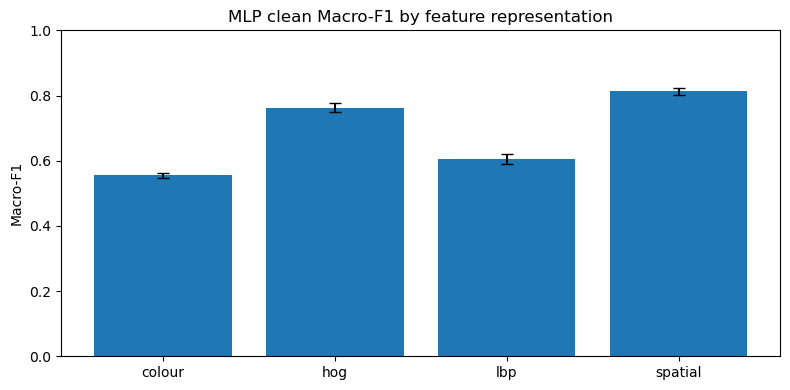

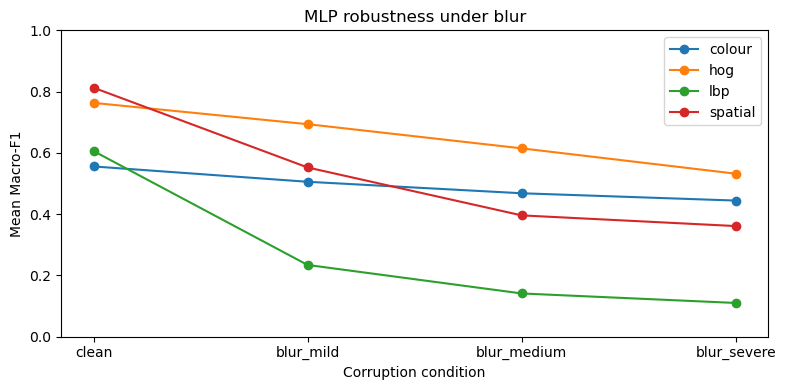

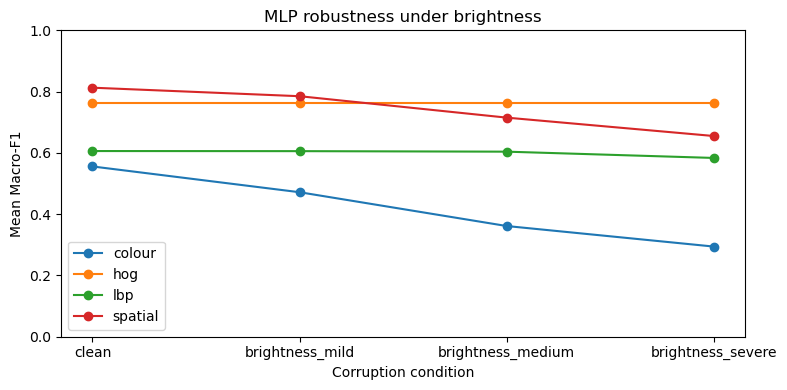

In [9]:
import matplotlib.pyplot as plt

clean_plot = (
    clean_results.groupby('feature_representation')['macro_f1']
    .agg(['mean', 'std'])
    .reindex(FEATURE_KEYS)
)
plt.figure(figsize=(8, 4))
plt.bar(clean_plot.index, clean_plot['mean'], yerr=clean_plot['std'], capsize=4)
plt.ylim(0, 1)
plt.ylabel('Macro-F1')
plt.title('MLP clean Macro-F1 by feature representation')
plt.tight_layout()
plt.show()

for corruption, conditions in {
    'blur': ['clean', 'blur_mild', 'blur_medium', 'blur_severe'],
    'brightness': ['clean', 'brightness_mild', 'brightness_medium', 'brightness_severe'],
}.items():
    plot_data = (
        results_df[results_df['condition'].isin(conditions)]
        .groupby(['condition', 'feature_representation'])['macro_f1']
        .mean()
        .unstack()
        .reindex(conditions)
    )
    plt.figure(figsize=(8, 4))
    for feature_key in FEATURE_KEYS:
        plt.plot(plot_data.index, plot_data[feature_key], marker='o', label=feature_key)
    plt.ylim(0, 1)
    plt.ylabel('Mean Macro-F1')
    plt.xlabel('Corruption condition')
    plt.title(f'MLP robustness under {corruption}')
    plt.legend()
    plt.tight_layout()
    plt.show()